## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.  

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/vegetation_condition_index/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  


# Vegetation Condition Index

## Overview

In this notebook, we will:
1. Connect to the CDSE openEO backend (https://openeo.dataspace.copernicus.eu/)
2. Define an area of interest containing vegetated land, such as Dodge City, United States
3. Define the selected date, the year range `[selected_year_from, selected_year_to]`, and the cloud masking method in the `job_meta` dictionary in `Config` section. The options for the cloud masking method are `"threshold"` and "`scl-dilation"`
3. Create cloud‑free scenes for the selected dates using the selected cloud masking method
4. Calculate NDVI from the cloud‑free scenes
6. Calculate the Vegetation Condition Index (VCI)

## Calculation of Vegetation Condition Index (VCI)

This notebook demonstrates how to calculate the Vegetation Condition Index (VCI) from Sentinel‑2 Normalized Difference Vegetation Index (NDVI) time series using openEO. 

Scenes are restricted to ±5 day calendar window around the anchor date (i.e. selected date). The scene stack includes the scenes at the **observed date** and at **historical dates**. 
- **Observed date**: the most recent acquisition within the ±5 day window (i.e. the scene closest to the anchor date). 
- **Historical dates**: all earlier acquisitions within the same ±5 day window - typically the same calendar period across prior years

VCI is calculated on cloud-free images as:

\begin{equation*}
\text{VCI} = \frac{\text{NDVI}_{\text{observed}} - \text{NDVI}_{\text{hist,min}}}{\text{NDVI}_{\text{hist,max}} - \text{NDVI}_{\text{hist,min}}}
\end{equation*}

## Pre‑processing Step to Create Cloud-Free Images

The Evalscript includes a pre‑processing step that removes cloudy pixels from Sentinel‑2 scenes acquired for the selected dates. In the reference Evalscript, cloud removal is based on a dedicated cloud mask band (e.g. `CLP`). However, openEO backends such as CDSE do not provide this band directly. As a workaround, we use the Scene Classification Layer (`SCL`) available in the Sentinel‑2 data on CDSE. Using the experimental openEO process `to_scl_dilation_mask`, the following SCL values will be removed to generate a cloud mask and filter out cloudy pixels (reference: [`to_scl_dilation_mask` documentation](https://docs.openeo.cloud/processes/#to_scl_dilation_mask)):
- 3 - Cloud shadows
- 8 - Clouds medium probability
- 9 - Clouds high probability
- 10 - Cirrus
- 11 - Snow/ice

Since the process is still experimental, the script also provides another option to mask clouds. The `isCloud` helper identifies clouds as pixels with values above the determined threshold for NGDR.

\begin{equation}
\text{NGDR} = \frac{\text{B03} - \text{B04}}{\text{B03} + \text{B04}}
\end{equation}

Clouds are also identified as pixels with B03 values above the threshold for bRatio (threshold-based method).

\begin{equation}
\text{bRatio} =\frac{\text{B03} - \text{0.175}}{\text{0.39} - \text{0.175}}  
\end{equation}

\begin{equation}
\text{clouds} = \text{(bRatio > 1.5) or (bRatio > 0.3 and NGDR > 0.3)}
\end{equation}


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [1]:
import rioxarray
import openeo
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from openeo.processes import and_, or_


## Connect to Copernicus (CDSE) backend

Connect to Copernicus (CDSE) openEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. The spatial extent below corresponds to Dodge City, Kansas, United States

In [3]:
# spatial_extent = {"west" : -100.48, "south" : 37.88, "east" : -100.28, "north" : 37.97}
spatial_extent = {"west" : -100.41, "south" : 37.91, "east" : -100.01, "north" : 38.06}

## Config
Options for cloud_masking_method = `"threshold"` or `"scl-dilation"`

In [4]:

job_meta = {
    "selected_date" : "2020-05-30",
    "selected_year_from" : 2018,
    "selected_year_to" : 2020,
    "cloud_masking_method" : "threshold"
}

## Helper Functions

### Constructing Sentinel-2 Scene Stack
`cube_scene_stack` helper: For each year in the range `year_from` and `year_to`, the helper pulls Sentinel-2 scenes over the same `tolerance_days` window on the calendar (same month and day, within the ±5 day window from the `anchor_date`). The scenes are filtered by cloud cover then merged into one cube. Where dates overlap, it keeps the pixels with maximum value.

In [5]:
def cube_scene_stack(
    connection: openeo.Connection,
    spatial_extent: dict,
    anchor_date: str,  
    year_from: int,
    year_to: int,
    tolerance_days: int = 5,
    bands: list[str] = ["B02", "B03", "B04", "B08"],
    max_cloud_cover: int | float = 80,
    collection_id: str = "SENTINEL2_L2A",
) -> openeo.rest.datacube.DataCube:
    """Load ±`tolerance_days` around (month, day) of `anchor_date` for each year in `[year_from, year_to]`, merge in time.

    Args:
        connection (openeo.Connection): 
            OpenEO client connection returned by e.g. `openeo.connect(...)`
        spatial_extent (dict): 
            Area of interest (bounding box dict or GeoJSON-style geometry), as the backend 
            Example: `spatial_extent = {"west" : -100.48, "south" : 37.88, "east" : -100.28, "north" : 37.97}`
        anchor_date (str):
            A selected date in a string object, must include date, month, year.
            Example: `"2020-05-30"`
        year_from (int): 
            First year or the earliest year in the range. Example: `2018`
        year_to (int):
            Last year or the most recent year in the range. Example: `2021`
        tolerance_days (int, optional): 
            Days before and after each year's anchor date. Defaults to 5.
        bands (list[str]): 
            Sentinel-2 band names to load. Band names should conform with the names listed in the selected openEO backend. 
            Defaults to `["B02", "B03", "B04", "B08"]`
        max_cloud_cover (int | float): 
            Maximum allowed scene-level cloud cover (percentage) for filtering granules. Defaults to 80.
        collection_id (str): 
            OpneEO collection identifier as recorded in the selected backend. Defaults to `"SENTINEL2_L2A"` for CDSE backend.

    Returns:
        openeo.rest.datacube.DataCube: 
            An openEO DataCube object that contains all Sentinel-2 scenes loaded for the requested area of interest, one short
            time window per year (around the `tolerance_days` window from the `anchor_date`), for every year from `year_from` through
            `year_to`, merged along the time dimension.  
    """
    anchor_date = datetime.strptime(anchor_date, "%Y-%m-%d")
    anchor_md = (anchor_date.month, anchor_date.day)
    cubes = []

    for year in range(year_from, year_to + 1):
        try:
            y_anchor = datetime(year, anchor_md[0], anchor_md[1])
        except ValueError:
            # e.g. Feb 29 in a non-leap year
            y_anchor = datetime(year, anchor_md[0], 28)

        t0 = y_anchor - timedelta(days=tolerance_days)
        t1 = y_anchor + timedelta(days=tolerance_days)

        c = connection.load_collection(
            collection_id,
            spatial_extent=spatial_extent,
            temporal_extent=[t0.strftime("%Y-%m-%d"), t1.strftime("%Y-%m-%d")],
            bands=bands,
            max_cloud_cover=max_cloud_cover,
        )
        cubes.append(c)

    merged = cubes[0]
    for c in cubes[1:]:
        merged = merged.merge_cubes(c, overlap_resolver="max")
    return merged

### Threshold-based Mask

In [6]:
# Masking clouds -> Returning True-False array
def isCloud(data):
    B03, B04 = (data[1], data[2])
    NGDR = (B03 - B04) / (B03 + B04)
    bRatio = (B03 - 0.175) / (0.39 - 0.175)
    return or_(bRatio > 1.5, and_(bRatio > 0.3, NGDR > 0.3))

### Cloud Mask Picker

In [7]:
CLOUD_METHOD_SLUG = {
    "scl-dilation" : "to_scl_dilation_mask",
    "threshold" : "isCloud"
}

def cloud_masking_workflow(data, process_name):
    # Must load SCL band of the selected date in the year range [year_from, year_to]
    process_name = CLOUD_METHOD_SLUG[process_name]
    if process_name == "to_scl_dilation_mask":
        scl_cube = cube_scene_stack(
            connection,
            spatial_extent,
            anchor_date=job_meta["selected_date"],
            year_from=job_meta["selected_year_from"],
            year_to=job_meta["selected_year_to"],
            tolerance_days=5,
            bands=["SCL"]
        )

        cloud_mask = scl_cube.process(
            process_name,
            data=scl_cube,
            kernel1_size=17, kernel2_size=31,
            mask1_values=[2, 4, 5, 6, 7],
            mask2_values=[3, 8, 9, 10, 11],
            erosion_kernel_size=0
        )

    if process_name == "isCloud":
        cloud_mask = data.apply_dimension(
            dimension="bands", process=globals()[process_name]
        )

    return cloud_mask

## Load Sentinel-2 L2A Product

In [8]:
# ±5 day slot every year from 2018 through 2020
s2cube = cube_scene_stack(
    connection,
    spatial_extent,
    anchor_date=job_meta["selected_date"],
    year_from=job_meta["selected_year_from"],
    year_to=job_meta["selected_year_to"],
    tolerance_days=5,
)

# To run the process in CDSE backend, need to scale reflectance from digital number to reflectance [0, 1]
s2cube = s2cube / 10000

## VCI Calculation

In [9]:
cloud_mask = cloud_masking_workflow(s2cube, job_meta["cloud_masking_method"])
s2cube_masked = s2cube.mask(cloud_mask)

# Calculate NDVI using openEO process 
ndvi_cube = s2cube_masked.ndvi(red="B04", nir="B08")

In [10]:
def vci_reducer(data):
    obs = data.last(ignore_nodata=True)
    ndvi_max = data.max(ignore_nodata=True)
    ndvi_min = data.min(ignore_nodata=True)
    denom = ndvi_max - ndvi_min
    vci = (obs - ndvi_min) / denom
    return vci

In [11]:
vci_cube = ndvi_cube.reduce_dimension(dimension="t", reducer=vci_reducer)

selected_method = job_meta['cloud_masking_method']
file_name = f"vci-{selected_method}.tif"
vci_cube.download(file_name)

## Metadata Formulation

In [12]:
# Save the observed and historical dates with available satellite scenes in a metadata
time_labels = s2cube.dimension_labels("t").execute()

In [14]:
# The format from dimension_labels() process
dt_format = "%a, %d %b %Y %H:%M:%S %Z" 

# Convert to datetime objects
dt_list = [datetime.strptime(d, dt_format) for d in time_labels]

# Find the observed date
observed_date = max(dt_list)

# Storing observed date and historical dates in a metadata dict for transparency
metadata = {
    "observed_date" : [str(observed_date.date())],
    "historical_date" : [str(date.date()) for date in dt_list if date != observed_date]
}

metadata

{'observed_date': ['2020-06-01'],
 'historical_date': ['2018-05-28',
  '2018-05-31',
  '2018-06-02',
  '2019-05-28',
  '2019-05-31',
  '2019-06-02',
  '2020-05-27',
  '2020-05-30']}

## Visualization

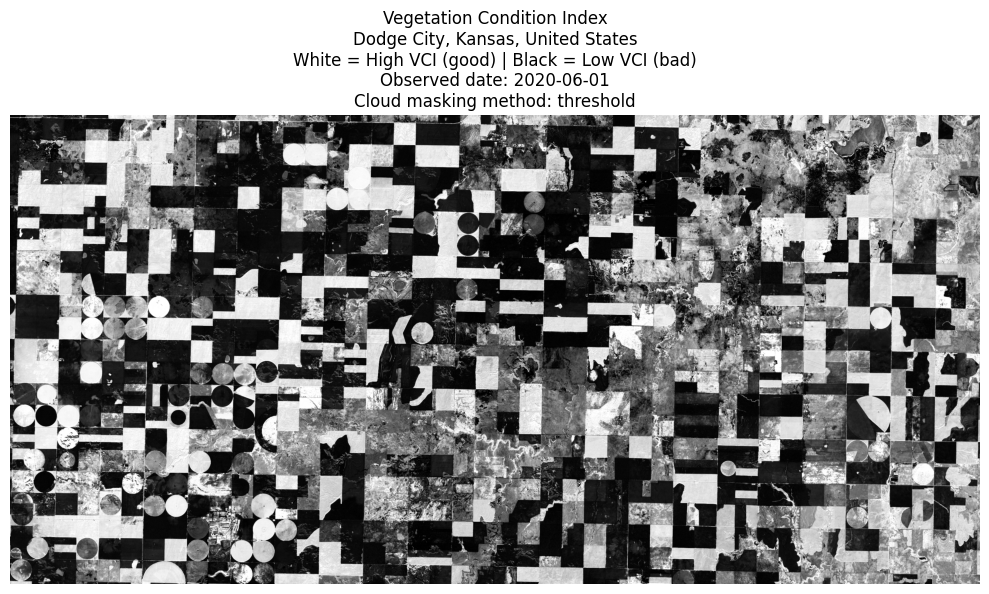

In [15]:
ds = rioxarray.open_rasterio(file_name).squeeze()

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(
    ds,
    cmap="gray",
    vmin=0,
    vmax=1,
    extent=[
        ds.x.values.min(),
        ds.x.values.max(),
        ds.y.values.min(),
        ds.y.values.max()
    ]
)
ax.set_title(
    "Vegetation Condition Index\n"
    "Dodge City, Kansas, United States\n"
    "White = High VCI (good) | Black = Low VCI (bad)\n"
    f"Observed date: {metadata["observed_date"][0]}\n"
    f"Cloud masking method: {job_meta["cloud_masking_method"]}",
    fontsize=12
)

ax.axis("off")

plt.tight_layout()
plt.show()

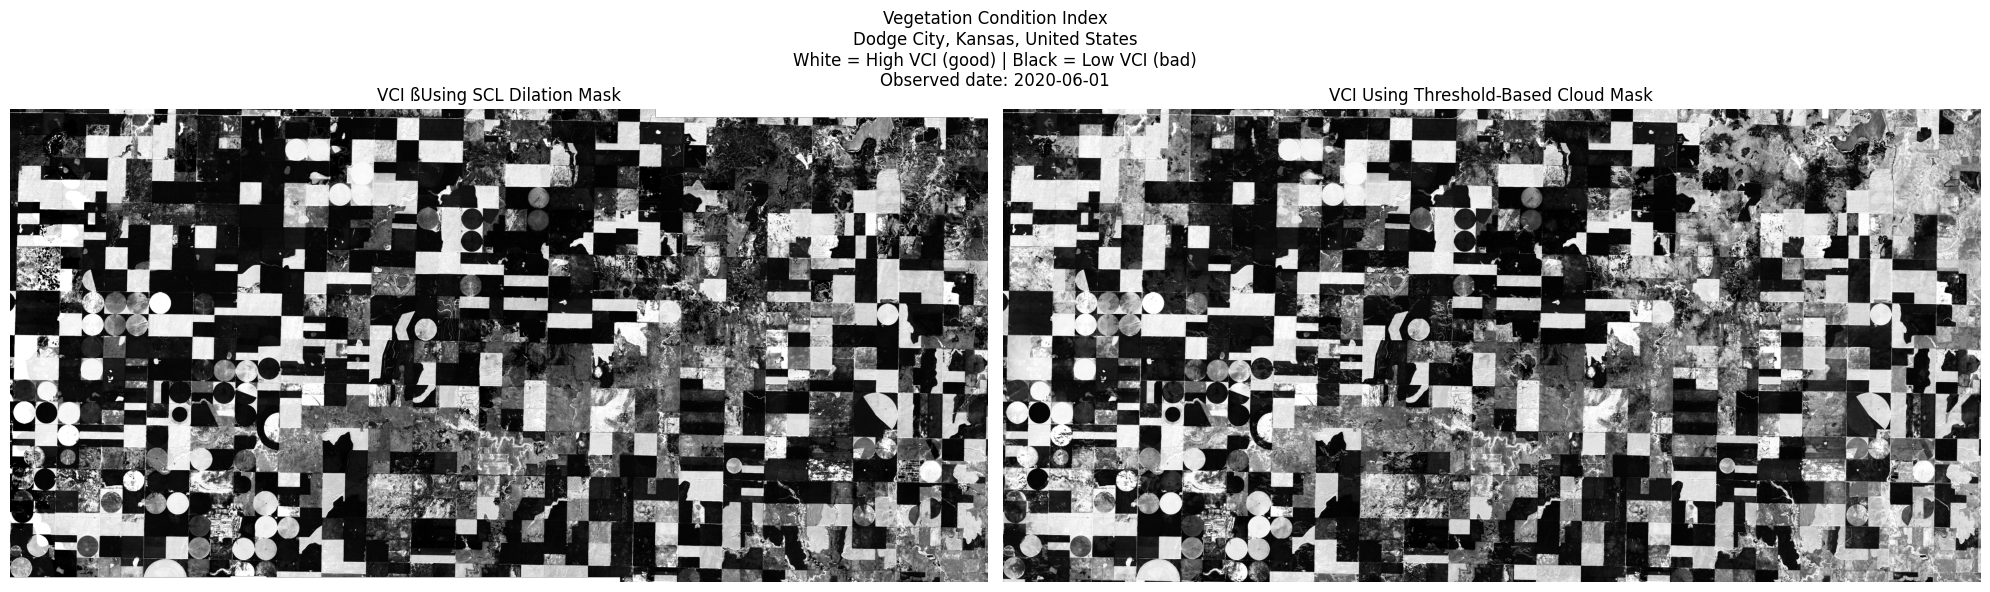

In [ ]:
# # Only run this block when VCIs from both cloud masking methods are produced

# ds_dilation = rioxarray.open_rasterio("vci-scl-dilation.tif").squeeze()
# ds_threshold = rioxarray.open_rasterio("vci-threshold.tif").squeeze()

# fig, axes = plt.subplots(1, 2, figsize=(20, 6))
# fig.suptitle(
#     "Vegetation Condition Index\n"
#     "Dodge City, Kansas, United States\n"
#     "White = High VCI (good) | Black = Low VCI (bad)\n"
#     f"Observed date: {metadata["observed_date"][0]}",
# )

# axes[0].imshow(
#     ds_dilation,
#     cmap="gray",
#     vmin=0,
#     vmax=1,
#     extent=[
#         ds_dilation.x.values.min(),
#         ds_dilation.x.values.max(),
#         ds_dilation.y.values.min(),
#         ds_dilation.y.values.max()
#     ]
# )
# axes[0].set_title("VCI ßUsing SCL Dilation Mask")

# axes[1].imshow(
#     ds_threshold,
#     cmap="gray",
#     vmin=0,
#     vmax=1,
#     extent=[
#         ds_threshold.x.values.min(),
#         ds_threshold.x.values.max(),
#         ds_threshold.y.values.min(),
#         ds_threshold.y.values.max()
#     ]
# )
# axes[1].set_title("VCI Using Threshold-Based Cloud Mask")

# for ax in axes.ravel():
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

## Interpretation Guide

### VCI Value Guide
| Color | Interpretation |
|-------|----------------------|
| Light Colors | NDVI on the observed date closer to historical maximum NDVI |
| Dark Colors | NDVI on the observed date closer to historical minimum NDVI |

### Method Overview
- Threshold-based cloud masking is sensitive to sun angle and seasonality. It is lightweight and reproducible, but fixed thresholds may not generalize well across all scenes.
- `to_scl_dilation_mask` can be more robust because it uses the precomputed SCL band. However, availability of both the process and SCL depends on the satellite product and backend, and the process is still experimental.
- VCI is conditioned by the selected reference year range `[year_from, year_to]`, which defines the historical NDVI minimum and maximum used for normalization.
- The workflow uses a +/-5-day calendar window around the anchor date for each year, merges those scenes into one time stack, and treats the latest available acquisition as the observed date.

### Applications
- Drought early warning: detect vegetation stress anomalies before visible crop failure.
- Agricultural monitoring: track crop condition through the season and flag fields with below-normal vigor.
- Yield risk assessment: support pre-harvest risk screening by linking persistent low VCI with likely yield reductions.
- Rangeland/pasture management: monitor forage condition for grazing planning and stocking decisions.
- Food security analysis: identify hotspots of vegetation stress to prioritize field checks or aid planning.
- Disaster impact assessment: quantify vegetation damage after heatwaves, floods, wildfire smoke, or pest outbreaks.
- Forest health: monitor prolonged stress that can increase vulnerability to disease, fire, or dieback.
- Water resource planning: use vegetation stress patterns as a proxy signal for irrigation demand and basin pressure.
- Climate adaptation baselining: compare current vegetation condition against historical windows to assess changing stress frequency.

VCI can give more insights when used with complementary indicators (e.g., rainfall anomalies, soil moisture, temperature, land cover type), since low VCI alone does not uniquely identify the stress driver.

## Citation
Liu, W. T., & Kogan, F. N. (1996). *Monitoring regional drought using the Vegetation Condition Index.
International Journal of Remote Sensing*, 17, 2761-2782.

The IDB Project. (2026). *Index: Vegetation Condition Index (VCI)*. IndexDatabase: https://www.indexdatabase.de/db/i-single.php?id=249

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Vegetation Condition Index](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/vegetation_condition_index/)

**Author:** (Author is not listed in the original script)

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.

## Conclusion

This notebook demonstrates the implementation of Vegetation Condition Index for Sentinel-2 for identifying stress using openEO. The notebook succesfully visualizes the differences in vegetation condition

The approach can be extended to:

- Create time-series animations to identify vegetation stress
- Integrate the outputs into early-warning systems of the driving causes of vegetation stress
- Validate results using ground-based observations and field data
- Enhance post-stress recovery monitoring by assessing vegetation growth over time